In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

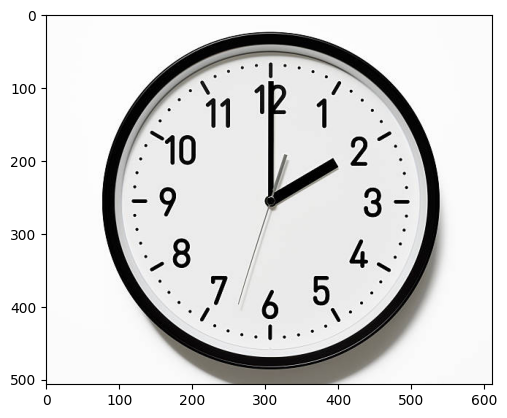

In [27]:
img = cv.imread("../../images/clock.jpg")
plt.imshow(img[...,::-1])

Text(0.5, 1.0, 'Transformed Image')

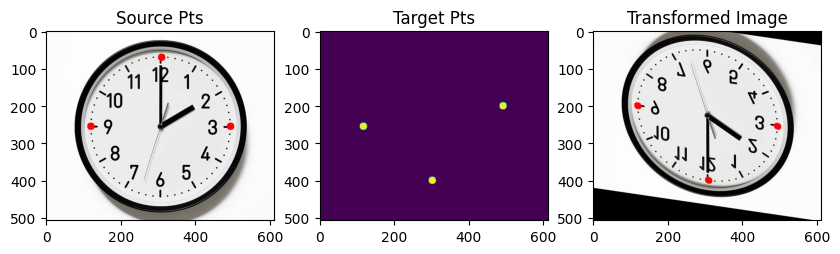

In [62]:
draw_img = img.copy()
blank = np.zeros(img.shape[:2], dtype="uint8")

source_pts = np.float32([
    [310, 70], # 12
    [120, 255], # 9
    [495, 255], # 3
])

target_pts = np.float32([
    [310, 400], # 12
    [120, 200], # 9
    [495, 255], # 3
])

for pts in source_pts:
    cv.circle(draw_img, np.int32(pts), 10, (0,0,255), -1)
for pts in target_pts:
    cv.circle(blank, np.int32(pts), 10, 255, -1)

M = cv.getAffineTransform(source_pts, target_pts)
output = cv.warpAffine(draw_img, M, draw_img.shape[:2][::-1])

plt.figure(figsize=(10,6))
plt.subplot(131); plt.imshow(draw_img[...,::-1]); plt.title("Source Pts")
plt.subplot(132); plt.imshow(blank[...,::-1]); plt.title("Target Pts")
plt.subplot(133); plt.imshow(output[...,::-1]); plt.title("Transformed Image")